In [1]:
# Импорт необходимых библиотек
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, count, when, avg, round, desc, month, year, datediff, to_date, lit
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, IntegerType, DateType
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Создание Spark сессии
spark = SparkSession.builder \
    .appName("Lab5_Returns_Analysis") \
    .master("local[*]") \
    .getOrCreate()

print("Spark версия:", spark.version)
print("Сессия создана успешно!")

26/03/01 21:48:54 WARN Utils: Your hostname, devopsvm resolves to a loopback address: 127.0.1.1; using 10.0.2.15 instead (on interface enp0s3)
26/03/01 21:48:54 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/01 21:49:01 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark версия: 3.5.5
Сессия создана успешно!


In [2]:
df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv("hdfs://localhost:9000/user/hadoop/lab_05/input/ecommerce_returns.csv")

print("Схема данных:")
df.printSchema()

print("\nПервые 5 строк:")
df.show(5, truncate=False)

print(f"\nВсего записей: {df.count()}")

Схема данных:
root
 |-- order_id: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- customer_id: integer (nullable = true)
 |-- product_id: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- product_price: integer (nullable = true)
 |-- order_status: string (nullable = true)
 |-- return_date: string (nullable = true)
 |-- return_reason: string (nullable = true)
 |-- return_quantity: integer (nullable = true)
 |-- refund_amount: integer (nullable = true)


Первые 5 строк:


+--------+----------+-----------+----------+----------------+-------+-------------+------------+-----------+----------------+---------------+-------------+
|order_id|order_date|customer_id|product_id|product_category|brand  |product_price|order_status|return_date|return_reason   |return_quantity|refund_amount|
+--------+----------+-----------+----------+----------------+-------+-------------+------------+-----------+----------------+---------------+-------------+
|1001    |2025-01-15|5001       |P101      |Electronics     |Samsung|45000        |returned    |2025-01-20 |defective       |1              |45000        |
|1002    |2025-01-15|5002       |P102      |Clothing        |Zara   |3500         |returned    |2025-01-22 |size_issue      |2              |7000         |
|1003    |2025-01-16|5003       |P103      |Books           |Penguin|800          |delivered   |NULL       |0               |0              |NULL         |
|1004    |2025-01-16|5001       |P104      |Electronics     |App


Всего записей: 13


In [4]:
# Проверка на null значения
print("Проверка на пропущенные значения:")
for column in df.columns:
    null_count = df.filter(col(column).isNull()).count()
    if null_count > 0:
        print(f"{column}: {null_count} пропусков")

# Предобработка данных
df_clean = df \
    .withColumn("order_date", to_date(col("order_date"), "yyyy-MM-dd")) \
    .withColumn("return_date", to_date(col("return_date"), "yyyy-MM-dd")) \
    .withColumn("is_returned", when(col("order_status") == "returned", 1).otherwise(0)) \
    .withColumn("days_to_return", 
                when(col("is_returned") == 1, datediff(col("return_date"), col("order_date")))
                .otherwise(lit(None))) \
    .withColumn("order_month", month("order_date")) \
    .withColumn("order_year", year("order_date"))

print("\nДанные после предобработки:")
df_clean.select("order_id", "order_date", "is_returned", "days_to_return", "return_reason").show(10)

Проверка на пропущенные значения:


refund_amount: 6 пропусков

Данные после предобработки:
+--------+----------+-----------+--------------+----------------+
|order_id|order_date|is_returned|days_to_return|   return_reason|
+--------+----------+-----------+--------------+----------------+
|    1001|2025-01-15|          1|             5|       defective|
|    1002|2025-01-15|          1|             7|      size_issue|
|    1003|2025-01-16|          0|          NULL|               0|
|    1004|2025-01-16|          1|             9|not_as_described|
|    1005|2025-01-17|          0|          NULL|               0|
|    1006|2025-01-18|          1|            10|      wrong_size|
|    1007|2025-01-18|          0|          NULL|               0|
|    1008|2025-01-19|          1|             8|       defective|
|    1009|2025-01-20|          0|          NULL|               0|
|    1010|2025-01-21|          0|          NULL|               0|
+--------+----------+-----------+--------------+----------------+
only showing top 10 

In [5]:
# Группировка по причинам возврата
returns_by_reason = df_clean \
    .filter(col("is_returned") == 1) \
    .groupBy("return_reason") \
    .agg(
        count("order_id").alias("return_count"),
        sum("refund_amount").alias("total_refund_amount"),
        round(avg("refund_amount"), 2).alias("avg_refund_amount"),
        round(avg("days_to_return"), 1).alias("avg_days_to_return")
    ) \
    .orderBy(desc("return_count"))

print("РЕЗУЛЬТАТ ЗАДАНИЯ 1:")
print("Статистика возвратов по причинам:")
returns_by_reason.show(truncate=False)

# Сохраняем для визуализации
returns_by_reason_pd = returns_by_reason.toPandas()

РЕЗУЛЬТАТ ЗАДАНИЯ 1:
Статистика возвратов по причинам:


+----------------+------------+-------------------+-----------------+------------------+
|return_reason   |return_count|total_refund_amount|avg_refund_amount|avg_days_to_return|
+----------------+------------+-------------------+-----------------+------------------+
|not_as_described|2           |121000             |60500.0          |7.5               |
|defective       |2           |110000             |55000.0          |6.5               |
|wrong_size      |1           |12000              |12000.0          |10.0              |
|size_issue      |1           |7000               |7000.0           |7.0               |
|quality_issues  |1           |13500              |13500.0          |8.0               |
+----------------+------------+-------------------+-----------------+------------------+



In [6]:
# Регистрируем временное представление для SQL
df_clean.createOrReplaceTempView("returns_data")

# Процент возвратов по категориям
print("ЗАДАНИЕ 2.1: Процент возвратов по категориям")
category_returns = spark.sql("""
    SELECT 
        product_category,
        COUNT(*) as total_orders,
        SUM(is_returned) as returned_orders,
        ROUND(SUM(is_returned) * 100.0 / COUNT(*), 2) as return_rate_percent,
        SUM(refund_amount) as total_refunds
    FROM returns_data
    GROUP BY product_category
    ORDER BY return_rate_percent DESC
""")
category_returns.show(truncate=False)

# Процент возвратов по брендам
print("\nЗАДАНИЕ 2.2: Процент возвратов по брендам")
brand_returns = spark.sql("""
    SELECT 
        brand,
        COUNT(*) as total_orders,
        SUM(is_returned) as returned_orders,
        ROUND(SUM(is_returned) * 100.0 / COUNT(*), 2) as return_rate_percent,
        SUM(refund_amount) as total_refunds
    FROM returns_data
    GROUP BY brand
    HAVING total_orders >= 2
    ORDER BY return_rate_percent DESC
""")
brand_returns.show(truncate=False)

# Сохраняем для визуализации
category_returns_pd = category_returns.toPandas()
brand_returns_pd = brand_returns.toPandas()

ЗАДАНИЕ 2.1: Процент возвратов по категориям


+----------------+------------+---------------+-------------------+-------------+
|product_category|total_orders|returned_orders|return_rate_percent|total_refunds|
+----------------+------------+---------------+-------------------+-------------+
|Electronics     |4           |4              |100.00             |231000       |
|Shoes           |2           |2              |100.00             |25500        |
|Clothing        |3           |1              |33.33              |7000         |
|Books           |2           |0              |0.00               |NULL         |
|Beauty          |2           |0              |0.00               |NULL         |
+----------------+------------+---------------+-------------------+-------------+


ЗАДАНИЕ 2.2: Процент возвратов по брендам


+-----+------------+---------------+-------------------+-------------+
|brand|total_orders|returned_orders|return_rate_percent|total_refunds|
+-----+------------+---------------+-------------------+-------------+
|Zara |2           |1              |50.00              |7000         |
+-----+------------+---------------+-------------------+-------------+



PySparkTypeError: [NOT_COLUMN_OR_STR] Argument `col` should be a Column or str, got list.

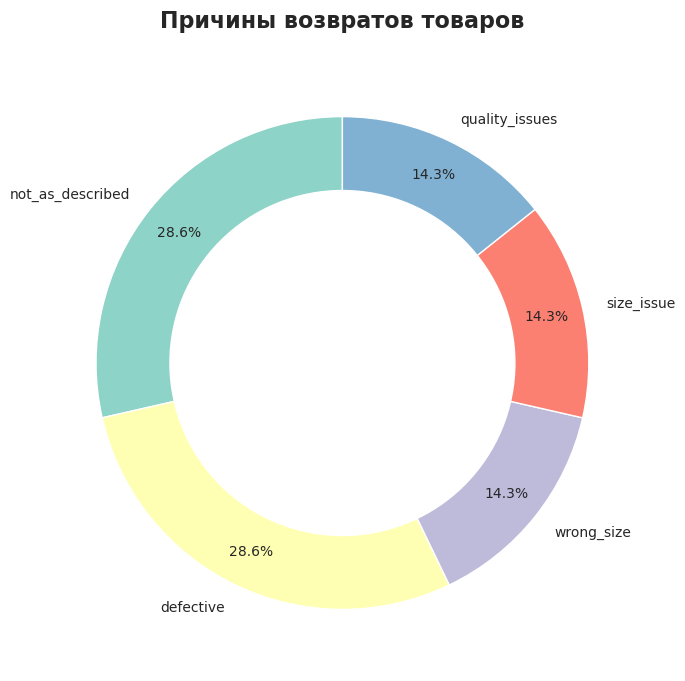

In [11]:
from pyspark.sql import functions as F 

reasons = returns_by_reason_pd['return_reason'].tolist()
counts = returns_by_reason_pd['return_count'].tolist()
colors = plt.cm.Set3(range(len(reasons)))

fig, ax = plt.subplots(figsize=(10, 8))

# Круговая диаграмма
wedges, texts, autotexts = ax.pie(
    counts, 
    labels=reasons,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.85,
    wedgeprops=dict(width=0.4, edgecolor='w')
)

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

ax.set_title('Причины возвратов товаров', fontsize=16, fontweight='bold', pad=20)

total_returns = sum(counts)
ax.text(0, 0, f"Всего\nвозвратов:\n{total_returns}", 
        ha='center', va='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('returns_by_reason_donut.png', dpi=300, bbox_inches='tight')
plt.show()